# Case 2: 2D Upper-Body Interpersonal Dynamics (MOSAIC) — reproduction

Pairs converse across four background-noise levels (Office 60 → Café 70 → Food
Court 80 → Party 87.5 dB SPL), each partner recorded by a dedicated webcam. Case 2
quantifies **interpersonal coordination** via cross-recurrence between the two
partners' ROI velocity-magnitude signals.

> **Data note.** The paper's dyadic figure needs *both* partners (the left- and
> right-camera files) across all 47 pairs. This notebook runs the **individual-level**
> pipeline (ROI velocity linear metrics only -- the paper never reports
> individual-level recurrence for Case 2) on whatever single-camera trials are
> present; the dyadic cross-recurrence entry point (`run_reproduction`) is included
> and runs once both-camera data is available.

## Configuration

In [3]:
import glob
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"G:\mosaic movement files"
from pose_dynamics.case_studies.mosaic import default_conditions_csv
CONDITIONS_CSV = default_conditions_csv()

files = sorted(f for f in glob.glob(f"{DATA_DIR}/*.csv") if not os.path.basename(f).startswith("._"))
print(f"{len(files)} camera files present")

550 camera files present


## 1. Load a trial and resolve ROIs

`load_mosaic_file` reads the name-based OpenPose export and keeps only the ROI
keypoints — the manuscript's BODY_25 groups (arms, upper body) plus the face
region — resolving them by name.

In [4]:
from pose_dynamics.case_studies.mosaic import load_mosaic_file

seq, roi_map = load_mosaic_file(files[0])
print(seq.summary())
print("ROIs (keypoints each):", {roi: len(idx) for roi, idx in roi_map.items()})

{'source_file': 'G:\\mosaic movement files\\S002_T1_left.csv', 'n_frames': 18001, 'n_keypoints': 62, 'dims': 2, 'frame_rate': 60.0, 'has_confidence': True, 'missing_fraction': 0.0003, 'stages_applied': []}
ROIs (keypoints each): {'arms': 6, 'upper_body': 4, 'centre_face': 54}


## 2. ROI velocity-magnitude signals

`roi_velocity_signals` runs the individual preprocessing (mask 0.30 → interpolate →
10 Hz filter → normalize to [0,1] → downsample to 30 Hz), aggregates each ROI to
its centroid, and takes the velocity magnitude — the one-dimensional movement-
intensity signal per ROI.

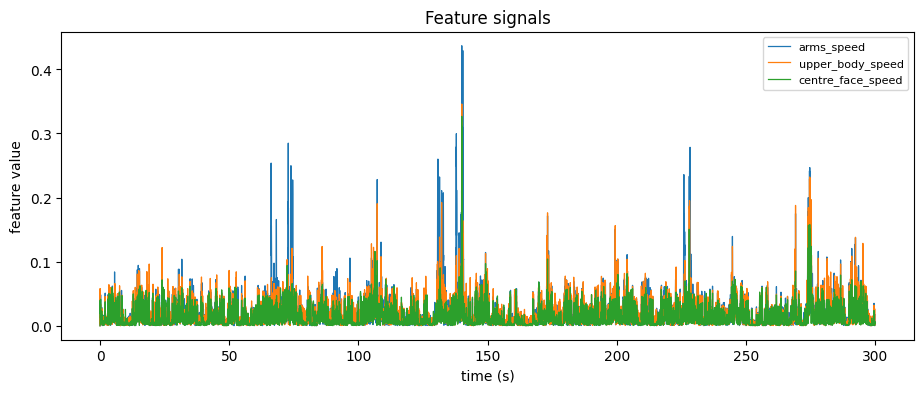

In [5]:
from pose_dynamics.case_studies.mosaic import roi_velocity_signals

feats = roi_velocity_signals(seq, roi_map)
feats.plot(names=[f"{r}_speed" for r in roi_map]);

## 3. Choosing the embedding parameters (human-in-the-loop)

At 30 Hz we estimate `(τ, m)` from AMI/FNN across the ROI signals, then commit.

C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],
C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],


Evidence from 40 of 1650 signals.

Delay (tau) — relative-shape / plateau heuristic (proposal, confirm from the plot):
  - first prominent local minimum (smoothed) at lag None.
  - plateau onset (diminishing returns) at lag 19.
  - relative 1/e crossing at lag 4.
  - per-signal median suggestion: 16.5.
  => proposed tau = 19.

Dimension (m) — FNN diminishing-returns knee at tau=19:
  - knee (elbow of the FNN curve): 4.
  - first dimension with FNN <= 10% (noise floor): None.
  - per-signal median: 4.0.
  => proposed m = 4.

NOTE: these are proposals, not decisions. Inspect the curves and their spread, then commit a single (tau, m) with evidence.commit(tau, m).


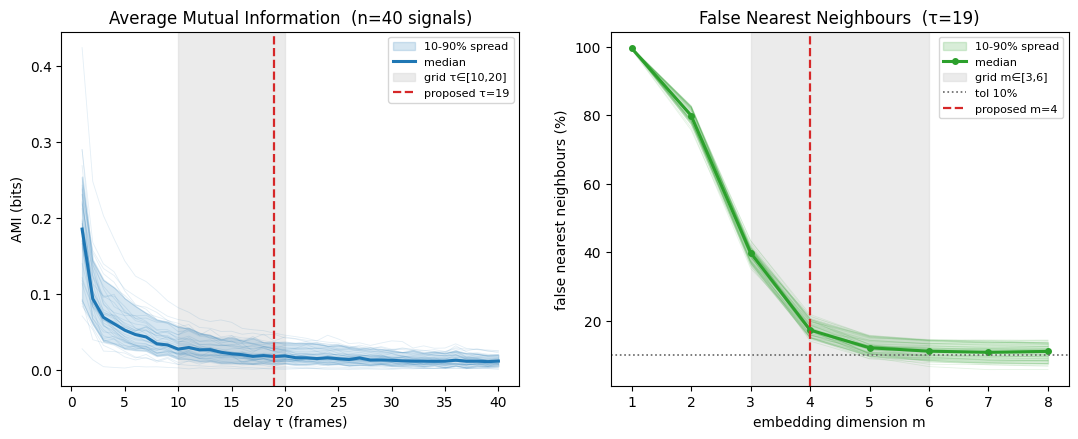

In [6]:
from pose_dynamics.embedding import select_embedding, Signal, plot_embedding_evidence

signals = []
for f in files:
    s, rm = load_mosaic_file(f)
    fs = roi_velocity_signals(s, rm)
    for roi in rm:
        signals.append(Signal(f"{Path(f).stem}_{roi}", fs.get(f"{roi}_speed"), group={"roi": roi}))

evidence = select_embedding(signals, tau_grid=(10, 20), m_grid=(3, 6),
                            ami_max_lag=40, fnn_max_dim=8, subset=40, seed=0)
plot_embedding_evidence(evidence)
print(evidence.justification)

In [7]:
params = evidence.commit(tau=10, m=4, notes="Case 2: committed from AMI/FNN")
params.to_dict()

{'tau': 10,
 'm': 4,
 'multivariate': False,
 'chosen_by': 'human_confirmed',
 'proposed_tau': 19,
 'proposed_m': 4,
 'n_signals': 40,
 'notes': 'Case 2: committed from AMI/FNN'}

## 4. Individual-level analysis (runnable now)

Per ROI, per 60 s window (50% overlap): RMS/mean/SD of velocity magnitude, grouped
by background-noise condition. No recurrence analysis here -- the paper's Case 2
individual-level results are linear-metrics only; dyadic CRQA is in Section 5.

In [8]:
from pose_dynamics.case_studies.mosaic import run_individual, plot_individual_figure

df = run_individual(files, CONDITIONS_CSV, progress=True)
print(f"{len(df)} window-rows")
df.groupby(["roi", "condition"], observed=True)[["rms", "mean_vel", "sd_vel"]].mean().round(4)

  S002_T1_left.csv: Office
  S002_T1_right.csv: Office
  S002_T2_left.csv: Food
  S002_T2_right.csv: Food
  S002_T3_left.csv: Office
  S002_T3_right.csv: Office
  S002_T4_left.csv: Cafe
  S002_T4_right.csv: Cafe
  S002_T5_left.csv: Office
  S002_T5_right.csv: Office
  S002_T6_left.csv: Party
  S002_T6_right.csv: Party
  S003_T1_left.csv: Office
  S003_T1_right.csv: Office
  S003_T2_left.csv: Cafe
  S003_T2_right.csv: Cafe
  S003_T3_left.csv: Office
  S003_T3_right.csv: Office
  S003_T4_left.csv: Party
  S003_T4_right.csv: Party
  S003_T5_left.csv: Office
  S003_T5_right.csv: Office
  S003_T6_left.csv: Food
  S003_T6_right.csv: Food
  S004_T1_left.csv: Office
  S004_T1_right.csv: Office
  S004_T2_left.csv: Party
  S004_T2_right.csv: Party
  S004_T3_left.csv: Office
  S004_T3_right.csv: Office
  S004_T4_left.csv: Food
  S004_T4_right.csv: Food
  S004_T5_left.csv: Office
  S004_T5_right.csv: Office
  S004_T6_left.csv: Cafe
  S004_T6_right.csv: Cafe
  S005_T1_left.csv: Office
  S005_T1_rig

C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],


  S039_T3_left.csv: Office
  S039_T3_right.csv: Office
  S039_T4_left.csv: Food
  S039_T4_right.csv: Food
  S039_T5_left.csv: Office
  S039_T5_right.csv: Office
  S039_T6_left.csv: Cafe
  S039_T6_right.csv: Cafe
  S040_T1_left.csv: Office
  S040_T1_right.csv: Office
  S040_T2_left.csv: Party
  S040_T2_right.csv: Party
  S040_T3_left.csv: Office
  S040_T3_right.csv: Office
  S040_T4_left.csv: Cafe
  S040_T4_right.csv: Cafe
  S040_T5_left.csv: Office
  S040_T5_right.csv: Office
  S040_T6_left.csv: Food
  S040_T6_right.csv: Food


C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],


  S041_T1_left.csv: Office
  S041_T1_right.csv: Office
  S041_T2_left.csv: Party
  S041_T2_right.csv: Party
  S041_T3_left.csv: Office
  S041_T3_right.csv: Office
  S041_T4_left.csv: Food
  S041_T4_right.csv: Food
  S041_T5_left.csv: Office
  S041_T5_right.csv: Office
  S041_T6_left.csv: Cafe
  S041_T6_right.csv: Cafe
  S042_T1_left.csv: Office
  S042_T1_right.csv: Office
  S042_T2_left.csv: Party
  S042_T2_right.csv: Party
  S042_T3_left.csv: Office
  S042_T3_right.csv: Office
  S042_T4_left.csv: Cafe
  S042_T4_right.csv: Cafe
  S042_T5_left.csv: Office
  S042_T5_right.csv: Office
  S042_T6_left.csv: Food
  S042_T6_right.csv: Food
  S043_T1_left.csv: Office
  S043_T1_right.csv: Office
  S043_T2_left.csv: Cafe
  S043_T2_right.csv: Cafe
  S043_T3_left.csv: Office
  S043_T3_right.csv: Office
  S043_T4_left.csv: Food
  S043_T4_right.csv: Food
  S043_T5_left.csv: Office
  S043_T5_right.csv: Office
  S043_T6_left.csv: Party
  S043_T6_right.csv: Party
  S045_T1_left.csv: Office
  S045_T1_rig

rms  mean_vel  sd_vel
roi         condition                          
arms        Office     0.0560    0.0365  0.0422
            Cafe       0.0589    0.0382  0.0445
            Food       0.0673    0.0439  0.0508
            Party      0.0772    0.0509  0.0577
centre_face Office     0.0299    0.0213  0.0208
            Cafe       0.0308    0.0220  0.0213
            Food       0.0336    0.0241  0.0231
            Party      0.0380    0.0272  0.0262
upper_body  Office     0.0455    0.0312  0.0324
            Cafe       0.0479    0.0324  0.0344
            Food       0.0512    0.0359  0.0361
            Party      0.0619    0.0415  0.0450

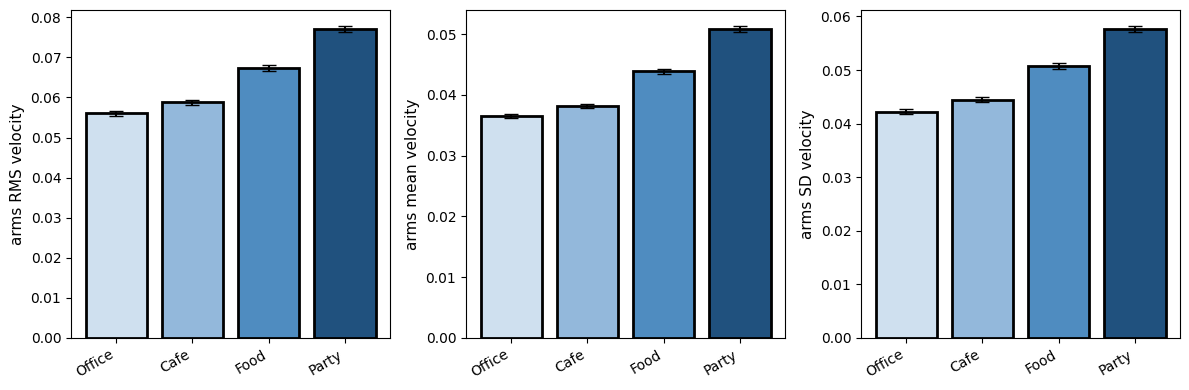

In [9]:
plot_individual_figure(df, roi="arms");

## 5. Dyadic reproduction (needs both partners)

This is the paper's analysis — interpersonal cross-recurrence between the two
partners' ROI signals, plus zero-lag velocity cross-correlation. It runs only when
both the `left` and `right` camera files are present for a session-trial.

In [10]:
from pose_dynamics.case_studies.mosaic import run_reproduction

try:
    dyad_df = run_reproduction(DATA_DIR, CONDITIONS_CSV, progress=True)
    dyad_df.groupby(["roi", "condition"], observed=True)[["cross_perc_recur", "cross_lmax", "xcorr_lag0"]].mean()
except FileNotFoundError as e:
    print("Dyadic reproduction unavailable:", e)

  session 2 trial 1 (Office)
  session 2 trial 2 (Food)
  session 2 trial 3 (Office)
  session 2 trial 4 (Cafe)
  session 2 trial 5 (Office)
  session 2 trial 6 (Party)
  session 3 trial 1 (Office)
  session 3 trial 2 (Cafe)
  session 3 trial 3 (Office)
  session 3 trial 4 (Party)
  session 3 trial 5 (Office)
  session 3 trial 6 (Food)
  session 4 trial 1 (Office)
  session 4 trial 2 (Party)
  session 4 trial 3 (Office)
  session 4 trial 4 (Food)
  session 4 trial 5 (Office)
  session 4 trial 6 (Cafe)
  session 5 trial 1 (Office)
  session 5 trial 2 (Food)
  session 5 trial 3 (Office)
  session 5 trial 4 (Party)
  session 5 trial 5 (Office)
  session 5 trial 6 (Cafe)
  session 6 trial 1 (Office)
  session 6 trial 2 (Party)
  session 6 trial 3 (Office)
  session 6 trial 4 (Food)
  session 6 trial 5 (Office)
  session 6 trial 6 (Cafe)
  session 7 trial 1 (Office)
  session 7 trial 2 (Food)
  session 7 trial 3 (Office)
  session 7 trial 4 (Party)
  session 7 trial 5 (Office)
  session 7 t

C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],


  session 39 trial 4 (Food)
  session 39 trial 5 (Office)
  session 39 trial 6 (Cafe)
  session 40 trial 1 (Office)
  session 40 trial 2 (Party)
  session 40 trial 3 (Office)
  session 40 trial 4 (Cafe)
  session 40 trial 5 (Office)
  session 40 trial 6 (Food)
  session 41 trial 1 (Office)


C:\Users\Cathy\Repositories\Pose-Dynamics\src\pose_dynamics\features\primitives.py:351: RuntimeWarning: Mean of empty slice
  [np.nanmean(pose.coords[:, np.asarray(idx, int), :], axis=1) for idx in self.rois.values()],


  session 41 trial 2 (Party)
  session 41 trial 3 (Office)
  session 41 trial 4 (Food)
  session 41 trial 5 (Office)
  session 41 trial 6 (Cafe)
  session 42 trial 1 (Office)
  session 42 trial 2 (Party)
  session 42 trial 3 (Office)
  session 42 trial 4 (Cafe)
  session 42 trial 5 (Office)
  session 42 trial 6 (Food)
  session 43 trial 1 (Office)
  session 43 trial 2 (Cafe)
  session 43 trial 3 (Office)
  session 43 trial 4 (Food)
  session 43 trial 5 (Office)
  session 43 trial 6 (Party)
  session 45 trial 1 (Office)
  session 45 trial 2 (Food)
  session 45 trial 3 (Office)
  session 45 trial 4 (Cafe)
  session 45 trial 5 (Office)
  session 45 trial 6 (Party)
  session 46 trial 1 (Office)
  session 46 trial 2 (Cafe)
  session 46 trial 3 (Office)
  session 46 trial 4 (Party)
  session 46 trial 5 (Office)
  session 46 trial 6 (Food)
  session 47 trial 1 (Office)
  session 47 trial 2 (Party)
  session 47 trial 3 (Office)
  session 47 trial 4 (Food)
  session 47 trial 5 (Office)
  sessio

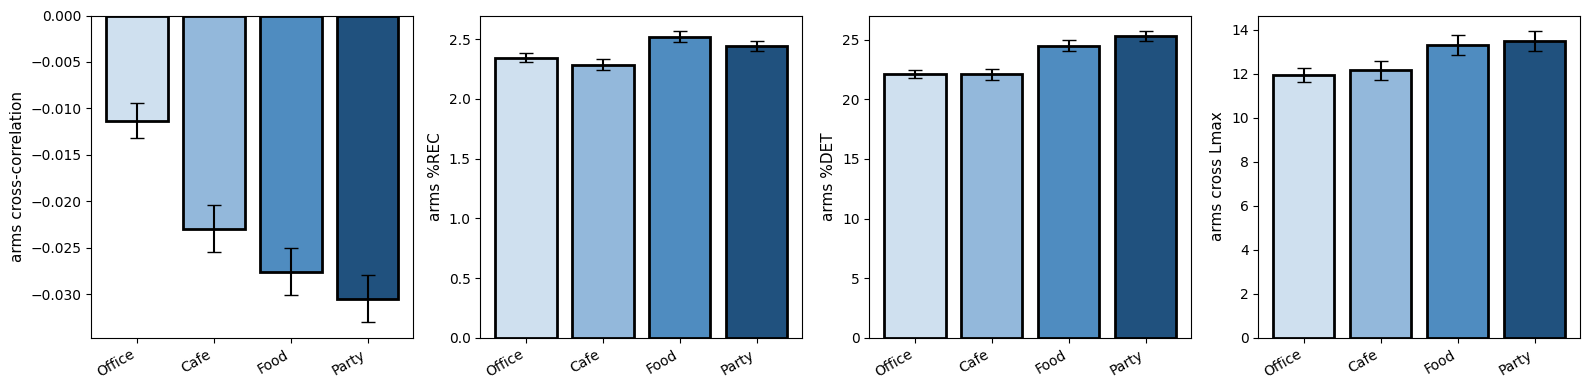

In [11]:
from pose_dynamics.case_studies.mosaic import plot_dyadic_figure

plot_dyadic_figure(dyad_df, roi="arms");

## 6. Inferential statistics (dataset-specific)

The package deliberately holds **no inferential statistics** — it emits the tidy
results tables. The models below are specific to *this* dataset and live only in
the notebook: linear mixed-effects models with a fixed effect of background-noise
condition (Office as reference), fit separately per ROI and per metric, matching
the paper's approach.

**Individual-level metrics** (RMS/mean/SD velocity): the paper uses random
intercepts for *pair* and *individual-within-pair* (nested). This simplifies that
to a single random intercept per participant (`session` + `camera`, since each
camera is a dedicated webcam per person) — close in spirit, but without the
separate pair-level variance component. **Dyadic metrics** (cross-correlation,
CRQA): random intercept for pair (`session`) only, matching the paper directly.

In [12]:
import statsmodels.formula.api as smf
import pandas as pd
import warnings; warnings.simplefilter("ignore")

df["participant"] = df["session"].astype(str) + "_" + df["camera"]

coef_rows = []
for roi in ["arms", "upper_body", "centre_face"]:
    sub = df[df["roi"] == roi]
    for metric in ["rms", "mean_vel", "sd_vel"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('Office'))",
                        sub, groups=sub["participant"]).fit()
        for term, label in [("C(condition, Treatment('Office'))[T.Cafe]", "Cafe"),
                            ("C(condition, Treatment('Office'))[T.Food]", "Food"),
                            ("C(condition, Treatment('Office'))[T.Party]", "Party")]:
            coef_rows.append({"roi": roi, "metric": metric, "vs_Office": label,
                              "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
pd.DataFrame(coef_rows).round(4)

,roi,metric,vs_Office,beta,SE,p
0,arms,rms,Cafe,0.0028,0.0006,0.0000
1,arms,rms,Food,0.0114,0.0006,0.0000
2,arms,rms,Party,0.0212,0.0006,0.0000
3,arms,mean_vel,Cafe,0.0017,0.0004,0.0000
4,arms,mean_vel,Food,0.0074,0.0004,0.0000
5,arms,mean_vel,Party,0.0145,0.0004,0.0000
6,arms,sd_vel,Cafe,0.0022,0.0005,0.0000
7,arms,sd_vel,Food,0.0087,0.0005,0.0000
8,arms,sd_vel,Party,0.0155,0.0005,0.0000
9,upper_body,rms,Cafe,0.0025,0.0006,0.0000


In [13]:
coef_rows = []
for roi in ["arms", "upper_body", "centre_face"]:
    sub = dyad_df[dyad_df["roi"] == roi]
    for metric in ["xcorr_lag0", "cross_perc_recur", "cross_perc_determ", "cross_lmax"]:
        m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('Office'))",
                        sub, groups=sub["session"]).fit()
        for term, label in [("C(condition, Treatment('Office'))[T.Cafe]", "Cafe"),
                            ("C(condition, Treatment('Office'))[T.Food]", "Food"),
                            ("C(condition, Treatment('Office'))[T.Party]", "Party")]:
            coef_rows.append({"roi": roi, "metric": metric, "vs_Office": label,
                              "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
pd.DataFrame(coef_rows).round(4)

,roi,metric,vs_Office,beta,SE,p
0,arms,xcorr_lag0,Cafe,-0.0116,0.0029,0.0001
1,arms,xcorr_lag0,Food,-0.0161,0.0029,0.0000
2,arms,xcorr_lag0,Party,-0.0192,0.0029,0.0000
3,arms,cross_perc_recur,Cafe,-0.0628,0.0506,0.2143
4,arms,cross_perc_recur,Food,0.1886,0.0502,0.0002
5,arms,cross_perc_recur,Party,0.0917,0.0504,0.0689
6,arms,cross_perc_determ,Cafe,-0.0401,0.4978,0.9358
7,arms,cross_perc_determ,Food,2.5185,0.4934,0.0000
8,arms,cross_perc_determ,Party,3.2040,0.4958,0.0000
9,arms,cross_lmax,Cafe,0.1992,0.5123,0.6974


## Notes

- **Name-based ROIs.** MOSAIC's OpenPose export uses named columns; the loader
  resolves the manuscript's BODY_25 ROI groups by name (arms, upper body) and the
  face region by substring, matching the prototype's name-based sets.
- **Individual vs. dyadic.** Movement intensity (RMS velocity) rising with
  background noise is recoverable per participant; the interpersonal coordination
  finding (cross-recurrence increasing with noise) requires both partners and is
  produced by `run_reproduction` once the full dataset is available.
- **Corrected alignment.** Like Case 1, this package's windowed Procrustes aligns
  correctly (fixed-direction rotation); the original pipeline's alignment code had
  a transpose bug that mis-rotated its aligned coordinates, so absolute values here
  will not bit-match it -- what should reproduce is the *pattern* (movement
  intensity rising with noise; interpersonal coordination measures shifting too).
- Stats require `statsmodels` (`pip install statsmodels`) -- a notebook dependency,
  not part of the core package. Section 6's individual-level model simplifies the
  paper's nested pair/individual-within-pair random effects to a single
  participant-level intercept -- see that section's note.